## Re-encode your c0.mp4 (signal head video) if check_fps_consistency says NOT CONSISTENT

In [ ]:
# run this command in terminal: 
# ffmpeg -i rawData/fourCams/c0.mp4 -vsync vfr -c:v libx264 -preset fast -crf 18 -pix_fmt yuv420p -vf fps=10 fixed_c0.mp4


## Making bounding box

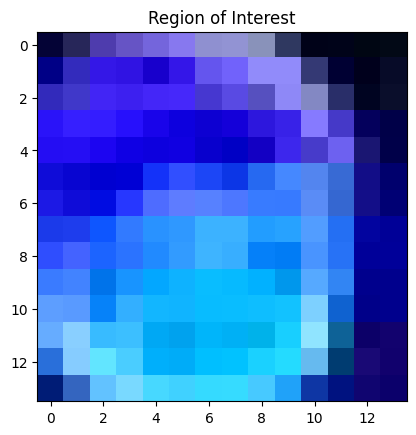

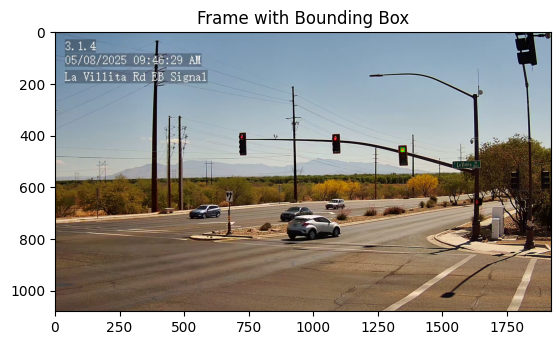

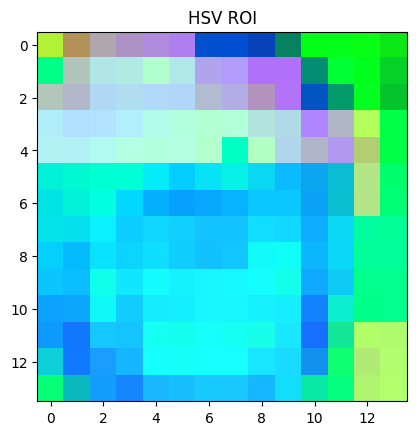

In [37]:
import cv2
from matplotlib import pyplot as plt

def draw_and_show_bounding_box(video_path, frame_number, box_coordinates):
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print("Error: Could not open video.")
        return
    
    # Set the frame position
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
    
    # Read the frame
    ret, frame = cap.read()
    cap.release()
    if not ret:
        print("Error: Could not read the frame.")
        return
    
    # Convert frame from BGR to RGB
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    
    # Extract ROI and convert to HSV
    x, y, width, height = box_coordinates
    roi = frame[y:y+height, x:x+width]
    hsv_roi = cv2.cvtColor(roi, cv2.COLOR_BGR2HSV)
    
    # Draw bounding box
    cv2.rectangle(frame_rgb, (x, y), (x + width, y + height), (0, 255, 0), 2)
    
    # Display ROI
    plt.imshow(roi)
    plt.axis('on')  # Show axis
    plt.title("Region of Interest")
    plt.show()
    
    # Display original frame with bounding box
    plt.imshow(frame_rgb)
    plt.title("Frame with Bounding Box")
    plt.show()
    
    # Display HSV version of ROI
    plt.imshow(hsv_roi)
    plt.title("HSV ROI")
    plt.show()

# Usage example
video_path = r"/home/sg1807/Desktop/sageena/cciPhase2/current/rawData/fourCams/c0.mp4"  # Update this with your video path
frame_number = 478  # Specify the frame number you want to extract
box_coordinates = (1336, 451, 14, 14)  # Example bounding box coordinates

draw_and_show_bounding_box(video_path, frame_number, box_coordinates)


## Finding yellow frame ranges

In [38]:
import cv2
import numpy as np

# Load the video
video_path = "/home/sg1807/Desktop/sageena/cciPhase2/current/rawData/fourCams/c0.mp4"  # Update with your video file
cap = cv2.VideoCapture(video_path)


# Define bounding box coordinates (14x14)
top_box = (1336, 451, 1350, 465)     # Top light
middle_box = (1337, 473, 1351, 487)  # Middle (Yellow) light
bottom_box = (1338, 494, 1352, 508)  # Bottom light




BRIGHTNESS_MARGIN = 2  # You can adjust this if needed


yellow_frames = []
frame_index = 0
yellow_detected = False
start_frame = None

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert to grayscale
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Crop out the three boxes
    top_light = gray[top_box[1]:top_box[3], top_box[0]:top_box[2]]
    middle_light = gray[middle_box[1]:middle_box[3], middle_box[0]:middle_box[2]]
    bottom_light = gray[bottom_box[1]:bottom_box[3], bottom_box[0]:bottom_box[2]]

    # Compute brightness (mean pixel intensity)
    top_brightness = np.mean(top_light)
    middle_brightness = np.mean(middle_light)
    bottom_brightness = np.mean(bottom_light)

    # If the middle box is brighter than the others, it's likely yellow
    if (middle_brightness > top_brightness + BRIGHTNESS_MARGIN and middle_brightness > bottom_brightness + BRIGHTNESS_MARGIN):

        if not yellow_detected:
            start_frame = frame_index  # Start of yellow light detection
            yellow_detected = True
    else:
        if yellow_detected:
            yellow_frames.append((start_frame, frame_index - 1))  # End of yellow light detection
            yellow_detected = False
            # print(start_frame)
            start_frame = None
            # print(start_frame)

    frame_index += 1

# If the yellow light is detected in the last frames and the video ends
if yellow_detected:
    yellow_frames.append((start_frame, frame_index - 1))

cap.release()

# Merge nearby yellow frame ranges
merged_yellow_frames = []
GAP_THRESHOLD = 20  # Adjust how many frames apart is considered "close enough" to merge

for start, end in yellow_frames:
    if not merged_yellow_frames:
        merged_yellow_frames.append((start, end))
    else:
        prev_start, prev_end = merged_yellow_frames[-1]
        if start <= prev_end + GAP_THRESHOLD:
            # Extend the previous range
            merged_yellow_frames[-1] = (prev_start, max(prev_end, end))
        else:
            # Start a new range
            merged_yellow_frames.append((start, end))

# Output merged frame ranges
print("Merged yellow light frame ranges:", merged_yellow_frames)
print(">>>-----------------------------------------------")

# Output frame ranges where yellow light is detected
print("Yellow light detected at frames:", yellow_frames)

Merged yellow light frame ranges: [(331, 370), (868, 907), (1403, 1442), (1979, 2017), (2478, 2517), (2858, 2897), (3426, 3465), (4001, 4040), (4796, 4835), (5347, 5386), (5733, 5771), (6142, 6181), (6874, 6913), (7527, 7566), (7907, 7946), (8369, 8408), (8959, 8998), (9996, 10035), (11204, 11243), (12218, 12257), (12820, 12859), (13220, 13259), (13831, 13870), (14790, 14828), (15512, 15551), (16044, 16083), (16506, 16545), (17062, 17101), (17603, 17642), (18290, 18329), (18963, 19002), (19537, 19576), (19996, 20035), (20950, 20989), (21407, 21446), (22098, 22137), (22662, 22701), (23227, 23266), (24157, 24195), (24641, 24680), (25204, 25242), (26201, 26240), (26738, 26777), (27480, 27519), (27953, 27992), (28533, 28572), (29073, 29112), (29844, 29883), (30276, 30315), (30869, 30908), (31283, 31322), (31814, 31853), (32447, 32485), (33083, 33122), (34061, 34100), (34592, 34631), (35362, 35401), (36013, 36052), (36706, 36745), (37341, 37380), (38182, 38220), (38987, 39026), (39798, 3983

## finding first synced frame

In [ ]:
import cv2
import os

def extract_50_frames(video_path, output_folder, start_frame):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print("Error: Could not open video.")
        return

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total frames in video: {total_frames}")

    if start_frame >= total_frames:
        print("Error: Start frame exceeds video length.")
        return

    # Go to the start frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    count = 1
    while count < 500:
        ret, frame = cap.read()
        if not ret:
            print("Reached end of video or read error.")
            break
        filename = os.path.join(output_folder, f"frame_{count:03d}.jpg")
        cv2.imwrite(filename, frame)
        count += 1

    cap.release()
    print(f"Extracted {count} frames to '{output_folder}'.")

# === Change these paths if needed ===
video_file = "/home/sg1807/Desktop/sageena/cciPhase2/current/rawData/fourCams/c1.mp4"
start_frame = 351402
output_dir = "/home/sg1807/Desktop/sageena/cciPhase2/current/frames/testing"

extract_50_frames(video_file, output_dir, start_frame)


Total frames in video: 118200
Extracted 500 frames to '/home/sg1807/Desktop/sageena/cciPhase2/current/frames/testing'.


## Syncing Clips

In [ ]:
import cv2
import os
import numpy as np
    
def extract_50_frames_from_input(videos_path, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    videos = os.listdir(videos_path)
    start_frame_offsets = {}
    
    for video in videos:
        video_path = os.path.join(videos_path, video)
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Error: Could not open video file {video_path}.")
            continue
        
        start_frame_offset = int(input(f"Enter the starting frame for {video}: "))
        start_frame_offsets[video] = start_frame_offset
        cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame_offset)
        
        frame_count = 0
        video_output_folder = os.path.join(output_folder, os.path.splitext(video)[0])
        if not os.path.exists(video_output_folder):
            os.makedirs(video_output_folder)
        
        while frame_count < 50:
            ret, frame = cap.read()
            if not ret:
                break
            frame_path = os.path.join(video_output_folder, f"frame_{frame_count + 1}.jpg")
            cv2.imwrite(frame_path, frame)
            frame_count += 1
        
        cap.release()
        print(f"Extracted {frame_count} frames from {video}")
    
    return start_frame_offsets

def get_starting_frames(videos):
    starting_frames = {}
    print("Enter the starting frame count for each video after synchronization:")
    for video in videos:
        start_frame = int(input(f"Starting frame for {video}: "))
        starting_frames[video] = start_frame
    return starting_frames

def is_frame_black(frame, threshold=10):

    """Returns True if the frame is mostly black (low average pixel intensity)."""

    return np.mean(frame) < threshold
 


def create_video_clip(start_frame, end_frame, video_path, fps=10):
    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Error: Could not open video file {video_path}.")
        return None

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    frame_count = start_frame
    frames = []
    last_valid_frame = None
    total_frames_needed = end_frame - start_frame + 1

    while len(frames) < total_frames_needed:
        ret, frame = cap.read()

        if not ret:
            print(f"[WARN] Frame {frame_count} could not be read in {video_path}.")
            if last_valid_frame is not None:
                frames.append(last_valid_frame.copy())
            else:
                print(f"[ERROR] No valid frame available to use at frame {frame_count}. Filling with black.")
                black_frame = np.zeros((720, 1280, 3), dtype=np.uint8)  # fallback resolution
                frames.append(black_frame)
        else:
            if is_frame_black(frame) and last_valid_frame is not None:
                print(f"[WARN] Suspected black frame at {frame_count} in {video_path}, using previous frame.")
                frames.append(last_valid_frame.copy())
            else:
                frames.append(frame)
                last_valid_frame = frame

        frame_count += 1

    cap.release()
    return frames

 
 

def stitch_frames(frames_list, output_file, fps=10):
    if not frames_list:
        print("Error: No frames to stitch.")
        return
    
    max_height = max(frame.shape[0] for frames in frames_list for frame in frames)
    layers = frames_list[0][0].shape[2]

    # Resize frames to the maximum height while maintaining the aspect ratio
    def resize_frame(frame, target_height):
        h, w = frame.shape[:2]
        aspect_ratio = w / h
        new_width = int(target_height * aspect_ratio)
        return cv2.resize(frame, (new_width, target_height), interpolation=cv2.INTER_AREA)

    resized_frames_list = [
        [resize_frame(frame, max_height) for frame in frames]
        for frames in frames_list
    ]

    # Determine total stitched width
    stitched_width = sum(frames[0].shape[1] for frames in resized_frames_list)
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_file, fourcc, fps, (stitched_width, max_height))

    for frames in zip(*resized_frames_list):
        stitched_frame = np.hstack(frames)  # Horizontally concatenate frames
        out.write(stitched_frame)
    
    out.release()
    print(f"Stitched video saved to {output_file}")

anchor_frames = {
    "c0.mp4": 3,
    "c1.mp4": 351402,
    "c2.mp4": 351429,
    "c3.mp4": 351432
}

videos_path = '/home/sg1807/Desktop/sageena/cciPhase2/current/rawData/fourCams'
# frames_output_folder = 'frames'
final_video_output_folder = '/home/sg1807/Desktop/sageena/cciPhase2/current/clips2'

# start_frame_offsets = extract_50_frames_from_input(videos_path, frames_output_folder)
videos = sorted([f for f in os.listdir(videos_path) if f.endswith(('.mp4', '.ts'))])
# starting_frames = get_starting_frames(videos)

yellow_frames = [(331, 370), (868, 907), (1403, 1442), (1979, 2017), (2478, 2517), (2858, 2897), (3426, 3465), (4001, 4040), (4796, 4835), (5347, 5386), (5733, 5771), (6142, 6181), (6874, 6913), (7527, 7566), (7907, 7946), (8369, 8408), (8959, 8998), (9996, 10035), (11204, 11243), (12218, 12257), (12820, 12859), (13220, 13259), (13831, 13870), (14790, 14828), (15512, 15551), (16044, 16083), (16506, 16545), (17062, 17101), (17603, 17642), (18290, 18329), (18963, 19002), (19537, 19576), (19996, 20035), (20950, 20989), (21407, 21446), (22098, 22137), (22662, 22701), (23227, 23266), (24157, 24195), (24641, 24680), (25204, 25242), (26201, 26240), (26738, 26777), (27480, 27519), (27953, 27992), (28533, 28572), (29073, 29112), (29844, 29883), (30276, 30315), (30869, 30908), (31283, 31322), (31814, 31853), (32447, 32485), (33083, 33122), (34061, 34100), (34592, 34631), (35362, 35401), (36013, 36052), (36706, 36745), (37341, 37380), (38182, 38220), (38987, 39026), (39798, 39837), (40371, 40410), (40873, 40911), (41342, 41381), (41899, 41938), (42688, 42727), (43275, 43314), (43840, 43879), (44269, 44308), (44702, 44741), (45887, 45926), (46267, 46306), (46872, 46911), (47474, 47513), (48596, 48635), (49197, 49236), (49623, 49662), (50063, 50101), (50599, 50638), (51267, 51306), (51904, 51943), (52319, 52358), (52726, 52765), (53662, 53701), (54062, 54101), (55022, 55061), (56122, 56161), (56712, 56751), (57298, 57337), (57720, 57759), (58785, 58824), (59472, 59511), (59988, 60027), (60675, 60714), (61297, 61336), (61822, 61861), (62353, 62392), (63106, 63145), (64386, 64425), (64866, 64905), (65545, 65584), (66100, 66139), (66746, 66785), (67165, 67204), (67916, 67955), (68418, 68457), (69291, 69330), (70194, 70233), (71068, 71107), (72006, 72044), (72496, 72534), (73136, 73175), (73837, 73876), (74393, 74432), (75080, 75119), (76051, 76090), (76531, 76570), (77078, 77117), (77931, 77970), (78661, 78700), (79156, 79195), (79708, 79747), (80666, 80705), (81156, 81195), (81574, 81613), (82255, 82294), (82677, 82716), (83287, 83326), (83844, 83883), (84556, 84595), (85301, 85340), (85715, 85754), (86270, 86309), (86997, 87036), (87667, 87706), (88352, 88391), (89560, 89599), (90552, 90591), (91477, 91516), (91937, 91975), (92536, 92575), (93689, 93728), (94582, 94621), (95497, 95535), (96106, 96145), (96655, 96694), (97273, 97312), (98327, 98366), (99157, 99196), (99764, 99803), (100594, 100633), (101198, 101237), (103190, 103229), (103873, 103912), (104496, 104534), (105164, 105203), (105561, 105600), (106259, 106298), (106717, 106756), (107217, 107256), (107803, 107842), (108255, 108294), (109102, 109141), (109527, 109566), (110193, 110232), (110857, 110896), (111495, 111534), (112376, 112415), (114446, 114485), (115382, 115421), (116153, 116192), (116737, 116776), (117320, 117359), (117853, 117892)]
# Example frame intervals

for idx, (start, end) in enumerate(yellow_frames):  # Iterate correctly over tuples
    frames_list = []
    for video_name in reversed(videos):
        relative_start = start - anchor_frames["c0.mp4"]
        relative_end = end - anchor_frames["c0.mp4"]

        actual_start = anchor_frames[video_name] + relative_start
        actual_end = anchor_frames[video_name] + relative_end

        # 8 seconds before and after
        start_frame_adj = actual_start - 80
        end_frame_adj = actual_end + 80


        video_path = os.path.join(videos_path, video_name)
        frames = create_video_clip(start_frame_adj, end_frame_adj, video_path)
        if frames:
            frames_list.append(frames)
    
    stitched_video_output = os.path.join(final_video_output_folder, f'La_Villita_Rd_EB_Signal_1_0508_{start}_{end}.mp4')
    stitch_frames(frames_list, stitched_video_output)

Stitched video saved to /home/sg1807/Desktop/sageena/cciPhase2/current/clips2/La_Villita_Rd_EB_Signal_1_0508_331_370.mp4


KeyboardInterrupt: 